In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

In [2]:
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / 'outputs' / 'data' / 'ridership.parquet'
df = pd.read_parquet(DATA_PATH)

In [3]:
y = df['trip_count'].asfreq('D').interpolate()

In [4]:
split_date = pd.Timestamp('2025-01-01')

train = y[y.index < split_date]
test = y[y.index >= split_date]

print(f"Train: {len(train)} days ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test: {len(test)} days ({test.index.min().date()} to {test.index.max().date()})")

Train: 1799 days (2020-01-29 to 2024-12-31)
Test: 365 days (2025-01-01 to 2025-12-31)


### SARIMA

SARIMA (Seasonal AutoRegressive Integrated Moving Average) models the series using three components: autoregression (today's value depends on recent past values), differencing (removing trend to achieve stationarity), and moving average (today's value depends on recent forecast errors). The seasonal component repeats this structure at a fixed lag. We use `s=7` because `s=365` (annual) is computationally infeasible for SARIMA.

Before fitting, verify stationarity using the Augmented Dickey-Fuller test and determine the differencing order (d).

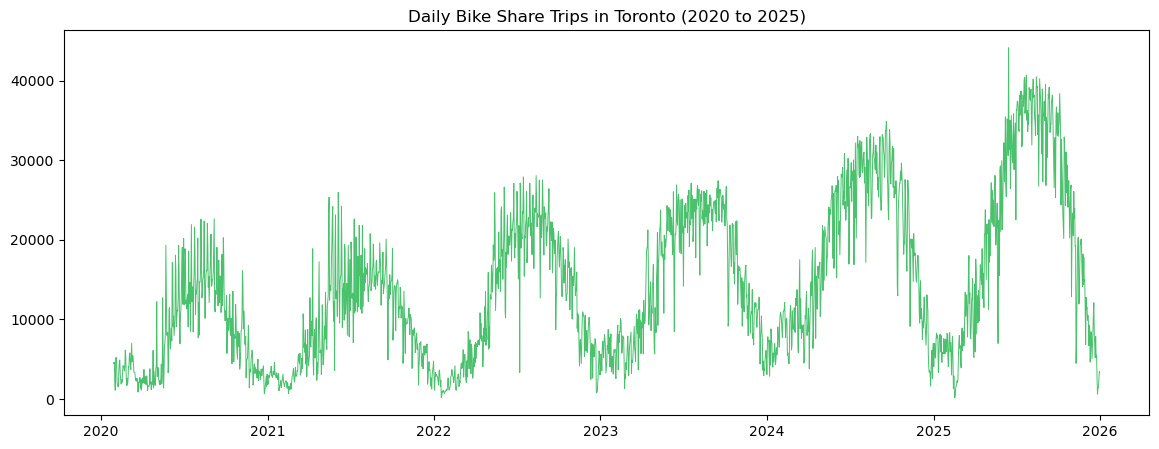

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 5))

# Sample of time series data
ax.plot(y, color='#4ac16d', linewidth=0.7)
ax.set_title('Daily Bike Share Trips in Toronto (2020 to 2025)')
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(y)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')

ADF Statistic: -2.3415
p-value: 0.1589


 In the context of an Augmented Dickey-Fuller (ADF) test, the null hypothesis ($H_0$) is that the series has a unit root (is non-stationary). Since the p-value is greater than 0.05 (standard level of significance), we fail to reject the null hypothesis. Therefore, the time series is non-stationary.

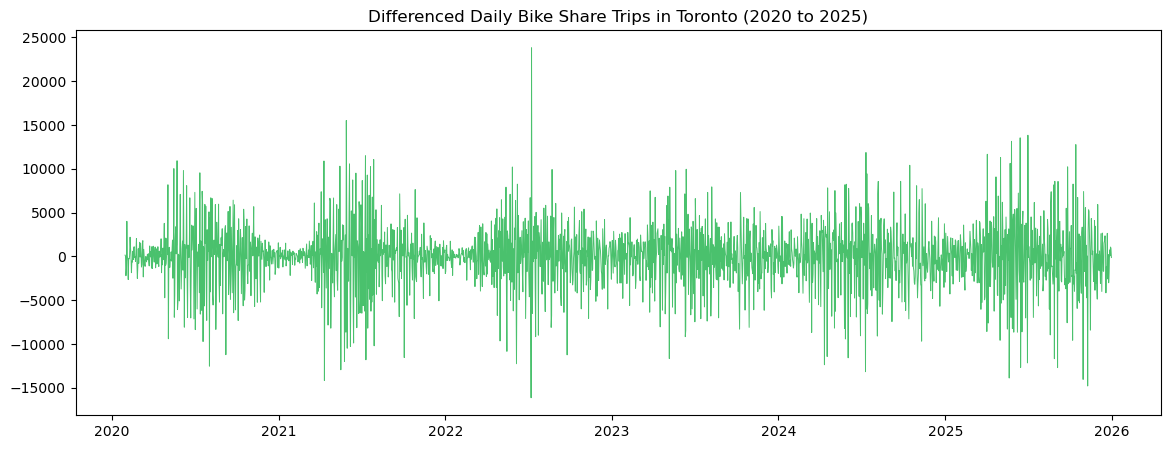

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

# Sample of time series data
ax.plot(y.diff(), color='#4ac16d', linewidth=0.7)
ax.set_title('Differenced Daily Bike Share Trips in Toronto (2020 to 2025)')
plt.show()

In [8]:
result_differenced = adfuller(y.diff().dropna()) # Removes the trend and only leaves the fluctuations
print(f'ADF Statistic: {result_differenced[0]:.4f}')
print(f'p-value: {result_differenced[1]}')

ADF Statistic: -8.8435
p-value: 1.6442983472923946e-14


The p-value is essentially zero, so the differenced series is stationary. For SARIMA to work properly, and in order to make the data stationary, one round of differencing (d=1) is needed.


In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,0,1,7))
fit = model.fit(disp=False)
print(fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                        trip_count   No. Observations:                 1799
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood              -16789.481
Date:                           Sun, 10 May 2026   AIC                          33588.963
Time:                                   14:34:22   BIC                          33616.435
Sample:                               01-29-2020   HQIC                         33599.104
                                    - 12-31-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2976      0.024     12.422      0.000       0.251       0.345
ma.L1         -0.8779      0.014    -63.425

In [10]:
pred = fit.get_forecast(steps=len(test))
y_pred_sarima = pred.predicted_mean

from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(test, y_pred_sarima)
rmse = root_mean_squared_error(test, y_pred_sarima)
mape = (abs(test - y_pred_sarima) / test).mean() * 100

print(f'MAE: {mae:.0f}')
print(f'RMSE: {rmse:.0f}')
print(f'MAPE: {mape:.1f}%')

MAE: 31997
RMSE: 35966
MAPE: 193.6%


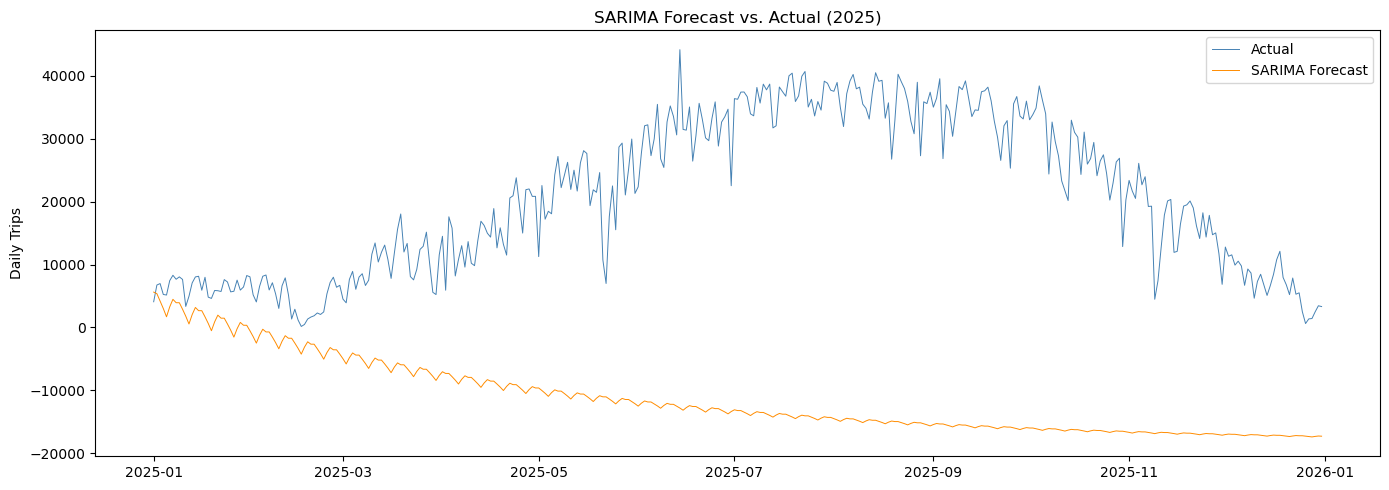

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test, label='Actual', color='steelblue', linewidth=0.7)
ax.plot(test.index, y_pred_sarima, label='SARIMA Forecast', color='darkorange', linewidth=0.7)
ax.set_title('SARIMA Forecast vs. Actual (2025)')
ax.set_ylabel('Daily Trips')
ax.legend()
plt.tight_layout()
plt.show()

### Prophet

Prophet is Facebook's additive regression model that decomposes the series into trend, weekly seasonality, yearly seasonality, and holiday effects. Unlike SARIMA, it handles multiple seasonal scales simultaneously and is robust to missing data and structural breaks. Adding Ontario statutory holidays as regressors allows the model to account for ridership changes due to holidays.

In [12]:
from prophet import Prophet
import holidays

# Prophet requires a DataFrame with ds and y columns
train_prophet = train.reset_index()
train_prophet.columns = ["ds", "y"]

# Build Canadian holidays DataFrame
ca_holidays = holidays.Canada(prov="ON", years=range(2020, 2026))
holidays_df = pd.DataFrame(
    [{"holiday": name, "ds": pd.Timestamp(date)} for date, name in ca_holidays.items()]
)

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=holidays_df
)
prophet_model.fit(train_prophet)

14:34:23 - cmdstanpy - INFO - Chain [1] start processing
python(28628) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
14:34:23 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
# Forecast over the test period
future = prophet_model.make_future_dataframe(periods=len(test))
forecast = prophet_model.predict(future)

# Extract just the test period predictions
y_pred_prophet = forecast.set_index("ds").loc[test.index, "yhat"]

mae_p = mean_absolute_error(test, y_pred_prophet)
rmse_p = root_mean_squared_error(test, y_pred_prophet)
mape_p = (abs(test - y_pred_prophet) / test).mean() * 100

print(f"MAE: {mae_p:.0f}")
print(f"RMSE: {rmse_p:.0f}")
print(f"MAPE: {mape_p:.1f}%")

MAE:  5707
RMSE: 6677
MAPE: 109.8%


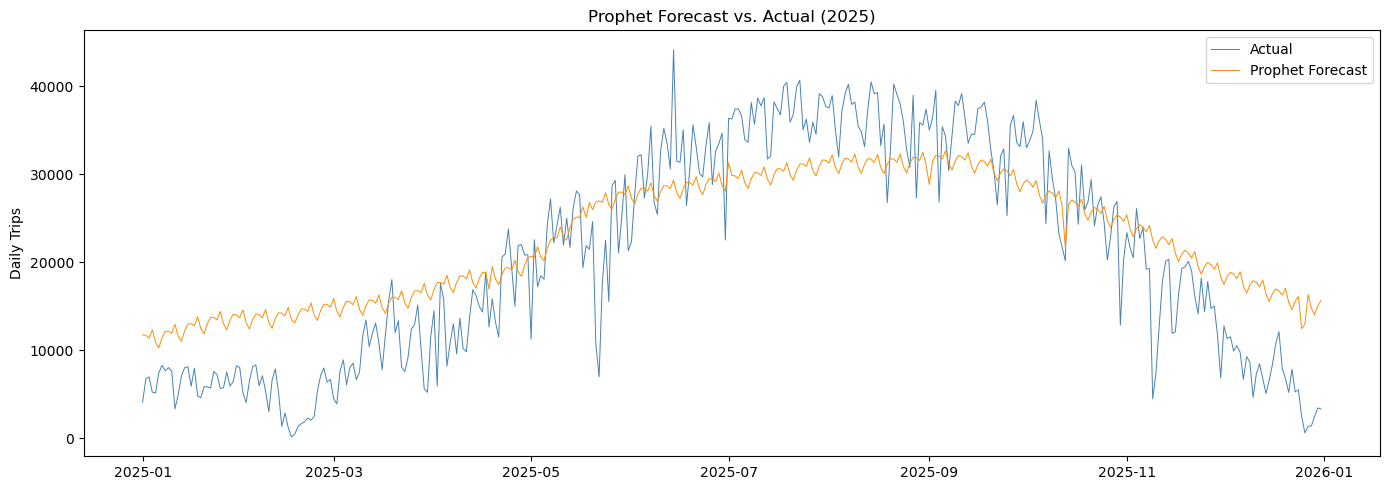

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test, label="Actual", color="steelblue", linewidth=0.7)
ax.plot(test.index, y_pred_prophet, label="Prophet Forecast", color="darkorange", linewidth=0.7)
ax.set_title("Prophet Forecast vs. Actual (2025)")
ax.set_ylabel("Daily Trips")
ax.legend()
plt.tight_layout()
plt.show()

### Holt-Winters (Triple Exponential Smoothing)

Holt-Winters (Triple Exponential Smoothing) extends simple exponential smoothing with separate components for level, trend, and seasonality. Each component has its own smoothing parameter that controls how quickly it adapts to new data. Use additive trend (ridership grows by a roughly constant amount year over year) and multiplicative seasonality (summer peaks are proportionally larger than winter troughs). With `seasonal_periods=365`, the model learns the full annual cycle directly.

The convergence warning is suppressed because the COVID-era structural break makes it difficult for the optimizer to find globally optimal smoothing parameters. The forecast quality (MAE ~3873) confirms the fit is adequate.

In [ ]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="mul",
    seasonal_periods=365
)

hw_fit = hw_model.fit()
y_pred_hw = hw_fit.forecast(steps=len(test))

mae_hw = mean_absolute_error(test, y_pred_hw)
rmse_hw = root_mean_squared_error(test, y_pred_hw)
mape_hw = (abs(test - y_pred_hw) / test).mean() * 100

print(f"MAE: {mae_hw:.0f}")
print(f"RMSE: {rmse_hw:.0f}")
print(f"MAPE: {mape_hw:.1f}%")

MAE:  3770
RMSE: 4913
MAPE: 47.6%


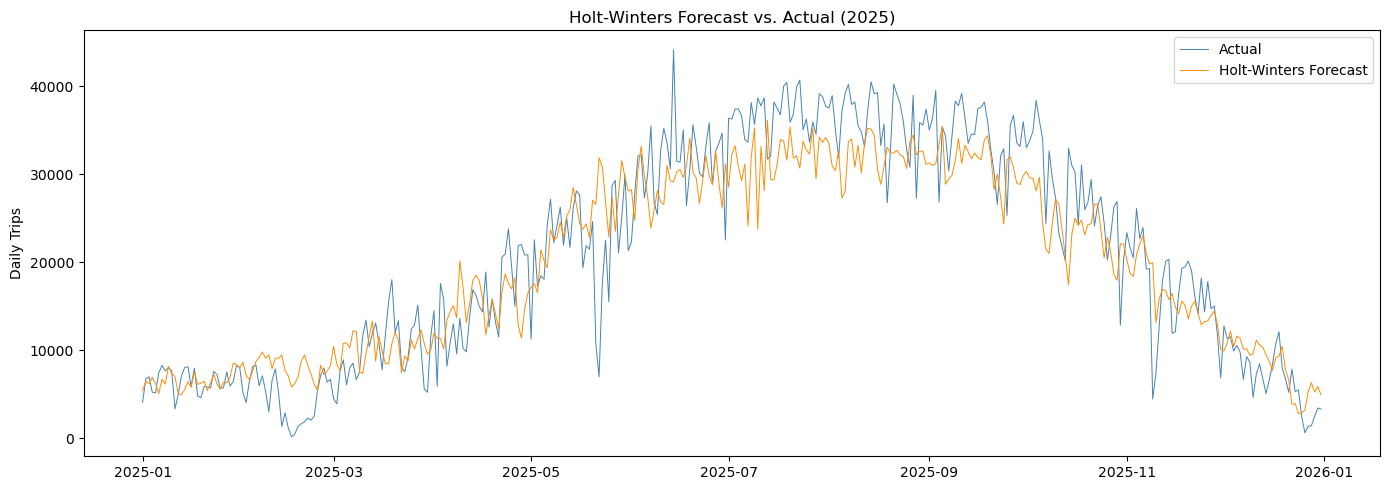

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test, label="Actual", color="steelblue", linewidth=0.7)
ax.plot(test.index, y_pred_hw, label="Holt-Winters Forecast", color="darkorange", linewidth=0.7)
ax.set_title("Holt-Winters Forecast vs. Actual (2025)")
ax.set_ylabel("Daily Trips")
ax.legend()
plt.tight_layout()
plt.show()

### XGBoost

Unlike the statistical models above, XGBoost is a supervised learning approach that treats forecasting as a regression problem. Instead of modelling the time series structure directly, it uses the engineered features from our feature pipeline (lag values, rolling averages, and calendar features) as input variables to predict daily trip counts. This gives it access to both weekly and annual patterns without needing to specify seasonal periods explicitly.

In [ ]:
from xgboost import XGBRegressor

# Reindex df to match the daily frequency used by y
df_daily = df.reindex(y.index).interpolate()

feature_cols = [c for c in df_daily.columns if c != "trip_count"]

X_train = df_daily.loc[train.index, feature_cols]
X_test = df_daily.loc[test.index, feature_cols]

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, train, verbose=False)
y_pred_xgb = pd.Series(xgb_model.predict(X_test), index=test.index)

mae_xgb = mean_absolute_error(test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(test, y_pred_xgb)
mape_xgb = (abs(test - y_pred_xgb) / test).mean() * 100

print(f"MAE: {mae_xgb:.0f}")
print(f"RMSE: {rmse_xgb:.0f}")
print(f"MAPE: {mape_xgb:.1f}%")

MAE:  3468
RMSE: 4299
MAPE: 29.7%


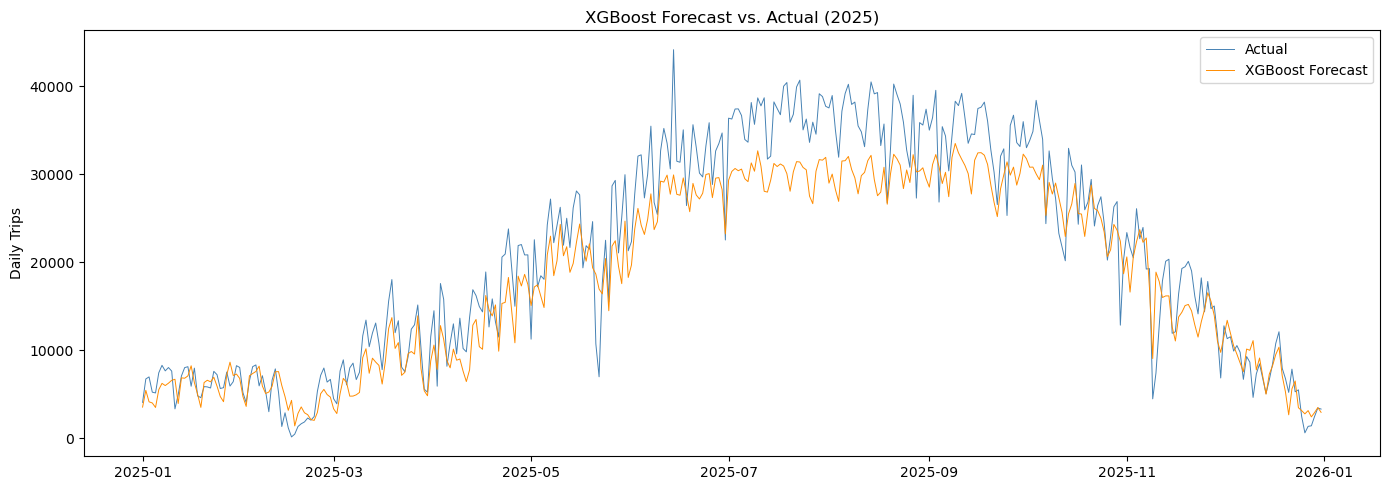

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test, label="Actual", color="steelblue", linewidth=0.7)
ax.plot(test.index, y_pred_xgb, label="XGBoost Forecast", color="darkorange", linewidth=0.7)
ax.set_title("XGBoost Forecast vs. Actual (2025)")
ax.set_ylabel("Daily Trips")
ax.legend()
plt.tight_layout()
plt.show()

## Model Comparison

With all four models fitted and evaluated on the 2025 hold-out period, their performance can be compared to one another.

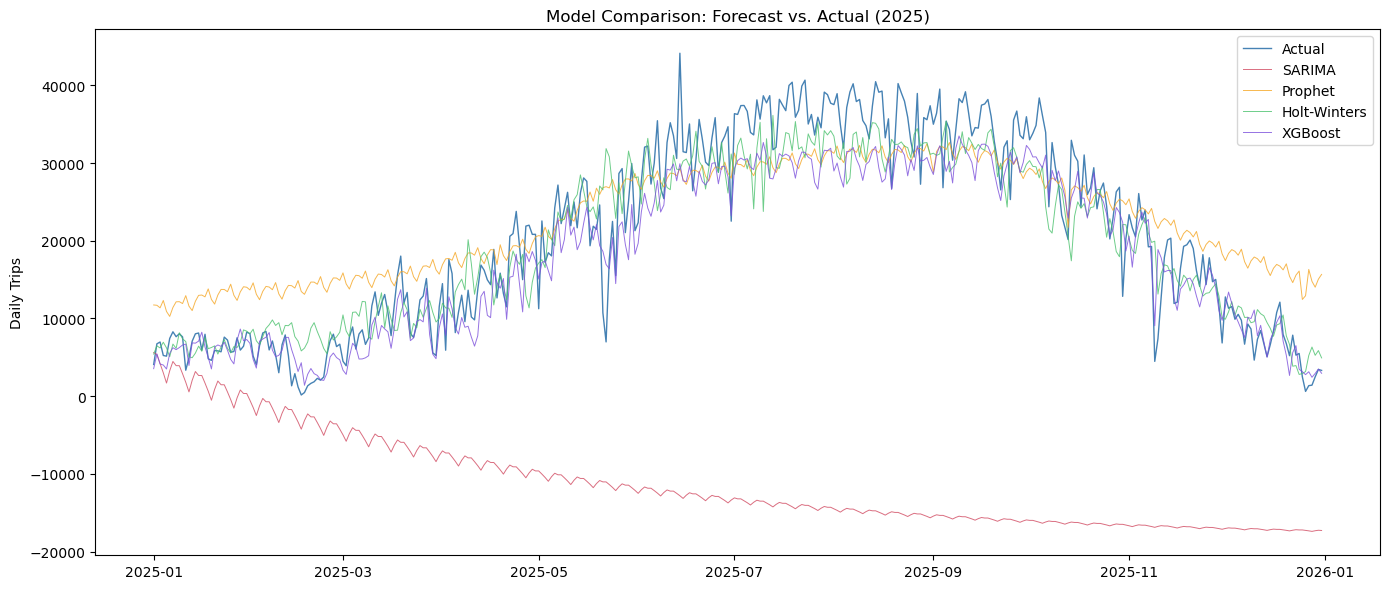

In [19]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test.index, test, label="Actual", color="steelblue", linewidth=1)
ax.plot(test.index, y_pred_sarima, label="SARIMA", color="#d14a61", linewidth=0.7, alpha=0.8)
ax.plot(test.index, y_pred_prophet, label="Prophet", color="#f5a623", linewidth=0.7, alpha=0.8)
ax.plot(test.index, y_pred_hw, label="Holt-Winters", color="#4ac16d", linewidth=0.7, alpha=0.8)
ax.plot(test.index, y_pred_xgb, label="XGBoost", color="#7b4fdb", linewidth=0.7, alpha=0.8)
ax.set_title("Model Comparison: Forecast vs. Actual (2025)")
ax.set_ylabel("Daily Trips")
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "Holt-Winters", "XGBoost"],
    "MAE": [mae, mae_p, mae_hw, mae_xgb],
    "RMSE": [rmse, rmse_p, rmse_hw, rmse_xgb],
    "MAPE (%)": [mape, mape_p, mape_hw, mape_xgb]
})
comparison = comparison.round(1)
comparison

,Model,MAE,RMSE,MAPE (%)
0,SARIMA,31997.0,35966.3,193.6
1,Prophet,5706.7,6677.4,109.8
2,Holt-Winters,3770.1,4913.1,47.6
3,XGBoost,3468.3,4299.2,29.7


## Interpretations

The four models reveal a clear hierarchy in their ability to forecast Toronto Bike Share ridership over a full year.

**SARIMA**, configured with weekly seasonality (`s=7`), captured day-to-day autocorrelation but had no mechanism to model the annual summer peak, resulting in a nearly flat forecast and the worst performance across all metrics. Setting `s=365` is computationally infeasible for SARIMA, which is an architectural limitation of the model.

**Prophet** performed significantly better by automatically decomposing the series into weekly and yearly seasonal components. It captured the overall shape of the annual cycle but consistently underpredicted summer ridership, likely because of COVID (2020-2021), which pulled the trend downward.

**Holt-Winters** with annual seasonality (`seasonal_periods=365`) delivered strong results, learning the seasonal shape directly from the repeating annual pattern across five years of training data. Its multiplicative seasonality handled the fact that summer variance is proportionally larger than winter variance.

**XGBoost** approached the problem differently. It is a supervised regression using engineered features (lags, rolling averages, calendar variables) rather than modelling the time series structure directly. This gave it access to both short-term autocorrelation and long-term seasonal patterns simultaneously.

For a real transit planner, the choice depends on the use case. For short-term operational planning (next week's bike rebalancing), any model with strong weekly patterns works. For annual capacity planning and budgeting, Holt-Winters or XGBoost would be the practical choice, as they capture the full seasonal arc that drives infrastructure decisions.